<a href="https://colab.research.google.com/github/musishxo/house_price_analysis-SCB/blob/main/House_price_analysis_SCB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Analysis

## Syfte

Syftet med detta projekt är att analysera utvecklingen av bostadspriser i Sverige med hjälp av Python och öppna data från Statistiska centralbyrån (SCB).

Projektet kommer att undersöka hur bostadspriser har förändrats över tid och om det finns skillnader mellan olika svenska regioner.

## Frågeställning

**Hur har bostadspriserna utvecklats över tid i olika svenska regioner, och vilka skillnader kan identifieras mellan regionerna?**

## Metod

I projektet kommer data att hämtas från SCB:s öppna data. Datan kommer sedan att bearbetas och analyseras med Python.

Analysen kommer bland annat att innehålla:

* datarensning och förberedelse
* deskriptiv statistik
* jämförelse mellan regioner
* visualisering av prisutvecklingen
* beräkning av procentuell förändring
* analys av samband mellan variabler
* en enklare prediktiv analys

Resultaten kommer att visualiseras med hjälp av diagram och sammanfattas i en avslutande analys och reflektion.


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**pandas** - läsa,struktera och analysera data
**numpy** - Matematiska beräkringar
**matplotlib** - skapa diagram

##  Datainsamling

I denna del kommer jag att använda Statistiska centralbyrån (SCB) som datakälla.

Jag kommer att hämta statistik om bostadspriser från SCB:s API. Datan innehåller information om bland annat genomsnittliga bostadspriser, antal försäljningar och geografiska områden i Sverige.



In [53]:
# Testar först att anslutningen till SCB:s API fungerar.
# try/except gör att programmet kan hantera anslutningsfel utan att krascha direkt.

import requests

url = "https://statistikdatabasen.scb.se/api/v2/tables"

try:
    response = requests.get(url, timeout=30)
    response.raise_for_status()

    print("Anslutningen till SCB fungerar!")

except requests.exceptions.RequestException as error:
    print("Ett fel uppstod:", error)

Anslutningen till SCB fungerar!


requests.get() - skickar en förfrågan till SCB:s API.

response.raise_for_status()  - kontrollerar om servern returnerar ett HTTP-fel.

try/except - hanterar anslutningsfel utan att programmet avslutas oväntat.

In [54]:
# Hämtar metadata från SCB:s tabell.
# Metadata beskriver vilka variabler och värden som finns i datasetet.
metadata_url = "https://statistikdatabasen.scb.se/api/v2/tables/TAB3656"

try:
    metadata_response = requests.get(metadata_url, timeout=30)
    metadata_response.raise_for_status()
    metadata = metadata_response.json()
    print("Metadata har hämtats från SCB!")
except requests.exceptions.RequestException as error:
    print("Ett fel uppstod vid hämtning av metadata:", error)


Metadata har hämtats från SCB!


## Hämtning av bostadsdata

Bostadsdata hämtas från SCB:s tabell.

I analysen används:
- Riket som region
- Medelpris för småhus som mått på bostadspris
- Alla tillgängliga tidsperioder


In [55]:
# Själva analysen använder redan kända variabelkoder i query nedan.
# Därför hämtas metadata här innan variablerna skrivs ut.

data_url = "https://statistikdatabasen.scb.se/api/v2/tables/TAB3656/data"

# Hämta bostadsdtan : valt Sverige, medelpris och alla tidsperioder
query = {
    "selection": [
        {
            "variableCode": "Region",
            "valueCodes": ["00"]
        },
        {
            "variableCode": "ContentsCode",
            "valueCodes": ["BO0501AJ"]
        },
        {
            "variableCode": "Tid",
            "valueCodes": ["*"]
        }
    ]
}

try:
    response = requests.post(
        data_url,
        json=query,
        params={"outputFormat": "json-stat2"},
        timeout=30
    )

    response.raise_for_status()
    house_price_data = response.json()

    print("Bostadsdata har hämtats från SCB!")

except requests.exceptions.RequestException as error:
    print("Ett fel uppstod vid hämtning av data:", error)

print("Antal observationer:", len(house_price_data["value"]))
print("Första observationerna:")
print(house_price_data["value"][:10])

Bostadsdata har hämtats från SCB!
Antal observationer: 353
Första observationerna:
[731, 739, 748, 752, 758, 748, 738, 730, 739, 754]


## Spara bostadsdata

Efter att bostadsdata har hämtats från SCB sparas datan som en CSV-fil.
Det gör det möjligt att använda datasetet senare i projektet utan att behöva hämta datan från SCB varje gång.

In [56]:
# Skapa en DataFrame med bostadspriserna

house_prices = pd.DataFrame({
    "Tid": house_price_data["dimension"]["Tid"]["category"]["label"].values(),
    "Medelpris": house_price_data["value"]
})

house_prices.head(10)

house_prices.to_csv("house_prices.csv", index=False)

print("CSV-filen har skapats!")


CSV-filen har skapats!


## Undersöka datasetet

Innan datan bearbetas undersöks datasetets struktur och innehåll.
Vi kontrollerar bland annat antal rader och kolumner, datatyper samt om det finns saknade värden.

In [57]:
# Undersök datasetets struktur

print("Antal rader:", house_prices.shape[0])
print("Antal kolumner:", house_prices.shape[1])

print("\nKolumner:")
print(house_prices.columns.tolist())

print("\nDatatyper:")
print(house_prices.dtypes)

# Kontrollera saknade värden
### isna() används för att kontrollera om datasetet innehåller saknade värden.

print("Saknade värden:")
print(house_prices.isna().sum())

# Beskrivande statistik för medelpriset
###describe() ger en sammanfattning av prisvariabeln.

house_prices["Medelpris"].describe()


Antal rader: 353
Antal kolumner: 2

Kolumner:
['Tid', 'Medelpris']

Datatyper:
Tid          object
Medelpris     int64
dtype: object
Saknade värden:
Tid          0
Medelpris    0
dtype: int64


,Medelpris
count,353.000000
mean,2257.932011
std,1028.502486
min,730.000000
25%,1331.000000
50%,2078.000000
75%,3042.000000
max,4168.000000


## Rensa och förbereda data

I detta steg förbereds datasetet inför den fortsatta analysen.
Vi kontrollerar datatyper, skapar en separat kolumn för år och kontrollerar att prisvärdena är rimliga.

In [58]:
# Visa de första tidsperioderna

print(house_prices["Tid"].head(10))

# Skapa en kolumn med året

house_prices["År"] = house_prices["Tid"].str[:4].astype(int)

house_prices.head(10)

# Kontrollera datatyper efter bearbetningen

print(house_prices.dtypes)

# Kontrollera årens intervall

print("Första året:", house_prices["År"].min())
print("Sista året:", house_prices["År"].max())
print("Antal olika år:", house_prices["År"].nunique())


0    1997M04
1    1997M05
2    1997M06
3    1997M07
4    1997M08
5    1997M09
6    1997M10
7    1997M11
8    1997M12
9    1998M01
Name: Tid, dtype: object
Tid          object
Medelpris     int64
År            int64
dtype: object
Första året: 1997
Sista året: 2026
Antal olika år: 30


## Resultat efter datarensning

Datasetet innehåller 353 observationer från 1997 till 2026.
Det finns inga saknade värden och medelpriset ligger mellan 730 och 4168 tusen kronor.

En separat kolumn för år har skapats från tidsvariabeln `Tid`, vilket gör datasetet enklare att använda i kommande analyser.

## Funktioner

För att göra koden mer återanvändbar skapas funktioner för olika delar av analysen.
På så sätt behöver samma kod inte skrivas om flera gånger.

In [59]:
# vi kan också använda Funktioner för att visa grundläggande information om datasetet

def visa_dataset_info(data):
    print("Antal rader:", data.shape[0])
    print("Antal kolumner:", data.shape[1])
    print("Kolumner:", data.columns.tolist())
visa_dataset_info(house_prices)

# Funktion för att visa statistik över medelpriset

def visa_prisstatistik(data):
    print("Prisstatistik:")
    print("Medelpris:", data["Medelpris"].mean())
    print("Median:", data["Medelpris"].median())
    print("Lägsta pris:", data["Medelpris"].min())
    print("Högsta pris:", data["Medelpris"].max())
visa_prisstatistik(house_prices)

# Funktion för att filtrera data efter år (vi tar år 2020 som exempel.)

def visa_data_for_ar(data, ar):
    resultat = data[data["År"] == ar]
    return resultat

data_2020 = visa_data_for_ar(house_prices, 2020)

data_2020.head()

# Funktion för att beräkna genomsnittligt pris per år

def genomsnitt_per_ar(data):
    resultat = data.groupby("År")["Medelpris"].mean()
    return resultat

pris_per_ar = genomsnitt_per_ar(house_prices)

pris_per_ar.head()

Antal rader: 353
Antal kolumner: 3
Kolumner: ['Tid', 'Medelpris', 'År']
Prisstatistik:
Medelpris: 2257.9320113314448
Median: 2078.0
Lägsta pris: 730
Högsta pris: 4168


,Medelpris
År,
1997,742.555556
1998,796.000000
1999,867.166667
2000,949.666667
2001,1061.166667


## Deskriptiv statistik

I detta steg analyseras bostadspriserna över tid med hjälp av årlig statistik.
Vi sammanställer det genomsnittliga medelpriset per år och beräknar procentuella förändringar över tid.


In [60]:
# Skapa en tabell med genomsnittligt bostadspris per år

arsstatistik = pris_per_ar.reset_index()

arsstatistik.columns = ["År", "Genomsnittligt medelpris"]

arsstatistik.head()

# Beräkna den totala procentuella förändringen

forsta_pris_1997 = arsstatistik["Genomsnittligt medelpris"].iloc[0]
sista_pris_2026 = arsstatistik["Genomsnittligt medelpris"].iloc[-1]

procentuell_forandring = ((sista_pris_2026 - forsta_pris_1997) / forsta_pris_1997) * 100

print("Förändring mellan första(1997) och sista året(2026):")
print(round(procentuell_forandring, 2), "%")

# Beräkna den procentuella förändringen mellan varje år

arsstatistik["Procentuell förändring"] = (
    arsstatistik["Genomsnittligt medelpris"].pct_change() * 100
)

arsstatistik.head()

Förändring mellan första(1997) och sista året(2026):
442.96 %


,År,Genomsnittligt medelpris,Procentuell förändring
0,1997,742.555556,NaN
1,1998,796.000000,7.197366
2,1999,867.166667,8.940536
3,2000,949.666667,9.513742
4,2001,1061.166667,11.740962


## Resultat av den årliga analysen

Den årliga analysen visar hur det genomsnittliga bostadspriset har förändrats över tid.

Mellan den första och sista tillgängliga årsgruppen ökade det genomsnittliga medelpriset med cirka 442,96 %.

Den procentuella förändringen från år till år varierar, vilket visar att prisutvecklingen inte varit exakt lika stor varje år.

## Visualiseringen

För att tydligare se hur bostadspriserna har utvecklats över tid skapas ett linjediagram.
Diagrammet visar det genomsnittliga medelpriset för varje år.

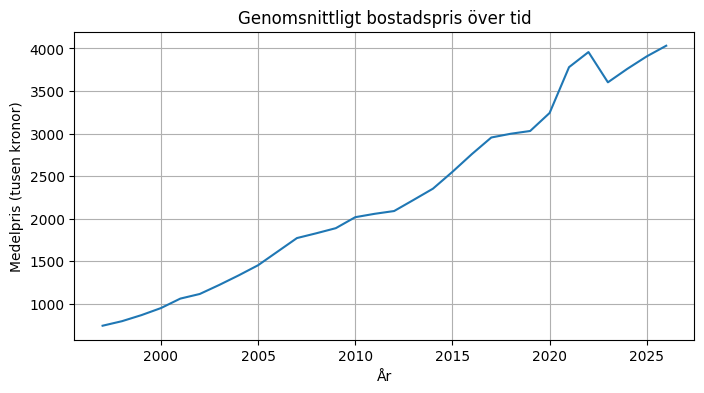

In [61]:
# Linjediagram över bostadsprisernas utveckling

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(
    arsstatistik["År"],
    arsstatistik["Genomsnittligt medelpris"]
)

plt.title("Genomsnittligt bostadspris över tid")
plt.xlabel("År")
plt.ylabel("Medelpris (tusen kronor)")
plt.grid(True)

plt.show()

## Regional jämförelse

I detta steg jämförs bostadspriserna mellan de olika regionerna i Sverige. Analysen fokuserar på både prisnivåer och procentuell förändring under den analyserade perioden.


In [62]:
# Hämtar samma mått från SCB, men nu för alla regioner.
# Regionkod '*' betyder att alla tillgängliga regioner hämtas.

regional_query = {
    "selection": [
        {
            "variableCode": "Region",
            "valueCodes": ["*"]
        },
        {
            "variableCode": "ContentsCode",
            "valueCodes": ["BO0501AJ"]
        },
        {
            "variableCode": "Tid",
            "valueCodes": ["*"]
        }
    ]
}

try:
    response = requests.post(
        data_url,
        json=regional_query,
        params={"outputFormat": "json-stat2"},
        timeout=30
    )

    response.raise_for_status()
    regional_data = response.json()

    print("Regional bostadsdata har hämtats från SCB!")

except requests.exceptions.RequestException as error:
    print("Ett fel uppstod vid hämtning av regional data:", error)

print("Antal värden:", len(regional_data["value"]))

print("Dimensioner:")
print(regional_data["id"])

print("\nStorlek:")
print(regional_data["size"])

regioner = list(
    regional_data["dimension"]["Region"]["category"]["label"].values()
)

tider = list(
    regional_data["dimension"]["Tid"]["category"]["label"].values()
)

regional_prices = pd.DataFrame({
    "Region": np.repeat(regioner, len(tider)),
    "Tid": tider * len(regioner),
    "Medelpris": regional_data["value"]
})

regional_prices.head()

print("Antal regioner:", regional_prices["Region"].nunique())

print("\nRegioner:")
print(regional_prices["Region"].unique())

regional_prices["År"] = regional_prices["Tid"].str[:4].astype(int)

regional_prices.head()

regional_statistik = (
    regional_prices
    .groupby("Region")["Medelpris"]
    .mean()
    .sort_values(ascending=False)
)

regional_statistik

regional_forandring = (
    regional_prices
    .groupby("Region")
    .agg(
        forsta_pris_1997=("Medelpris", "first"),
        sista_pris_2026=("Medelpris", "last")
    )
)

regional_forandring["Procentuell förändring"] = (
    (regional_forandring["sista_pris_2026"] - regional_forandring["forsta_pris_1997"])
    / regional_forandring["forsta_pris_1997"]
) * 100
regional_forandring["Procentuell förändring"] = (
    regional_forandring["Procentuell förändring"].round(2)
)

regional_forandring = regional_forandring.sort_values(
    "Procentuell förändring",
    ascending=False
)

regional_forandring


Regional bostadsdata har hämtats från SCB!
Antal värden: 8825
Dimensioner:
['Region', 'ContentsCode', 'Tid']

Storlek:
[25, 1, 353]
Antal regioner: 25

Regioner:
['Riket' 'Stor-Stockholm' 'Stor-Göteborg' 'Stor-Malmö' 'Stockholms län'
 'Uppsala län' 'Södermanlands län' 'Östergötlands län' 'Jönköpings län'
 'Kronobergs län' 'Kalmar län' 'Gotlands län' 'Blekinge län' 'Skåne län'
 'Hallands län' 'Västra Götalands län' 'Värmlands län' 'Örebro län'
 'Västmanlands län' 'Dalarnas län' 'Gävleborgs län' 'Västernorrlands län'
 'Jämtlands län' 'Västerbottens län' 'Norrbottens län']


,forsta_pris_1997,sista_pris_2026,Procentuell förändring
Region,,,
Gotlands län,633,4108,548.97
Stor-Malmö,868,5424,524.88
Hallands län,718,4454,520.33
Uppsala län,701,4259,507.56
Stor-Stockholm,1192,7140,498.99
Stockholms län,1192,7140,498.99
Stor-Göteborg,958,5618,486.43
Skåne län,731,4282,485.77
Västra Götalands län,725,4129,469.52


## Resultat av den regionala analysen

Den regionala analysen visar att bostadspriserna har ökat i samtliga 25 regioner under den analyserade perioden.

När de första och sista tillgängliga observationerna jämförs varierar den procentuella förändringen mellan regionerna. tex Riket(alla städer) hade en förändring på cirka 453,49 %, medan Gotlands län hade 548,97 % och Kalmar län 323,42 %.

Resultaten visar därmed att prisutvecklingen inte varit lika stor i alla regioner. Det finns regionala skillnader både i de genomsnittliga prisnivåerna och i hur mycket priserna har förändrats över perioden.

Det är viktigt att notera att jämförelsen baseras på den första och sista tillgängliga perioden i SCB:s dataset och därför inte ska tolkas som en jämförelse mellan två kompletta kalenderår.


## BostadsAnalys och RegionalAnalys

I detta steg används objektorienterad programmering (OOP) för att strukturera bostadsanalysen med hjälp av klasser och arv.

En basklass `BostadsAnalys` skapas för generell analys, medan `RegionalAnalys` ärver från basklassen och används för regional analys.


In [63]:
# Föräldrar class

class BostadsAnalys:
    def __init__(self, data):
        self.data = data

    def visa_info(self):
        print("Antal observationer:", len(self.data))
        print("Kolumner:", self.data.columns.tolist())

# Barn klass

class RegionalAnalys(BostadsAnalys):

    def visa_regioner(self):
        regioner = self.data["Region"].unique()
        print("Antal regioner:", len(regioner))
        print("Regioner:", regioner)

    def genomsnitt_per_region(self):
        resultat = (
            self.data
            .groupby("Region")["Medelpris"]
            .mean()
            .sort_values(ascending=False)
        )

        return resultat

    def analysera_region(self, region):
        resultat = self.data[self.data["Region"] == region]

        if resultat.empty:
            print("Regionen finns inte i datasetet.")
            return

        print("Region:", region)
        print("Antal observationer:", len(resultat))
        print(
            "Genomsnittligt medelpris:",
            round(resultat["Medelpris"].mean(), 2)
        )

# instans(objekt)

analys = BostadsAnalys(regional_prices)

regional_analys = RegionalAnalys(regional_prices)

regional_analys.visa_info()

regional_analys.visa_regioner()

pris_per_region = regional_analys.genomsnitt_per_region()

pris_per_region

regional_analys.analysera_region("Uppsala län")

Antal observationer: 8825
Kolumner: ['Region', 'Tid', 'Medelpris', 'År']
Antal regioner: 25
Regioner: ['Riket' 'Stor-Stockholm' 'Stor-Göteborg' 'Stor-Malmö' 'Stockholms län'
 'Uppsala län' 'Södermanlands län' 'Östergötlands län' 'Jönköpings län'
 'Kronobergs län' 'Kalmar län' 'Gotlands län' 'Blekinge län' 'Skåne län'
 'Hallands län' 'Västra Götalands län' 'Värmlands län' 'Örebro län'
 'Västmanlands län' 'Dalarnas län' 'Gävleborgs län' 'Västernorrlands län'
 'Jämtlands län' 'Västerbottens län' 'Norrbottens län']
Region: Uppsala län
Antal observationer: 353
Genomsnittligt medelpris: 2384.57


## Interaktiv regional analys

I detta steg utökas projektet med en interaktiv meny där användaren kan välja en region och få information om bostadspriserna för den valda regionen.


In [51]:
def valj_region(data):
    regioner = data["Region"].unique()

    print("Välj en region:")

    for nummer, region in enumerate(regioner, start=1):
        print(f"{nummer}. {region}")

    try:
        val = int(input("Ange nummer: "))

        if 1 <= val <= len(regioner):
            return regioner[val - 1]
        else:
            print("Ogiltigt val.")
            return None

    except ValueError:
        print("Du måste ange ett nummer.")
        return None

vald_region = valj_region(regional_prices)

if vald_region is not None:
    regional_analys.analysera_region(vald_region)


Välj en region:
1. Riket
2. Stor-Stockholm
3. Stor-Göteborg
4. Stor-Malmö
5. Stockholms län
6. Uppsala län
7. Södermanlands län
8. Östergötlands län
9. Jönköpings län
10. Kronobergs län
11. Kalmar län
12. Gotlands län
13. Blekinge län
14. Skåne län
15. Hallands län
16. Västra Götalands län
17. Värmlands län
18. Örebro län
19. Västmanlands län
20. Dalarnas län
21. Gävleborgs län
22. Västernorrlands län
23. Jämtlands län
24. Västerbottens län
25. Norrbottens län
Ange nummer: 2
Region: Stor-Stockholm
Antal observationer: 353
Genomsnittligt medelpris: 4183.92
